# Fase 5 — Network Analysis
> Dependensi: `mbg_analyzed.csv` harus sudah punya kolom `bert_topic`, `frame_bert`, `buzzer_suspect`

**Tujuan:**
1. Bangun graph dari relasi reply, mention, quote
2. Community detection (Louvain)
3. Centrality metrics (degree, betweenness)
4. Buzzer cluster check
5. Influencer per frame
6. Visualisasi network

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import os
import sys
sys.path.append('../Src')
from Src.config import ANALYZED_DATA, FIG_DIR

fig_net_dir = str(FIG_DIR / 'network')
os.makedirs(fig_net_dir, exist_ok=True)

df = pd.read_csv(ANALYZED_DATA)
print(f"Shape: {df.shape}")
print(f"Kolom: {df.columns.tolist()}")

Shape: (15000, 57)
Kolom: ['date', 'lang', 'source', 'user_id', 'hashtags', 'is_quote', 'mentions', 'tweet_id', 'username', 'verified', 'full_text', 'created_at', 'quoted_url', 'view_count', 'quote_count', 'quoted_text', 'reply_count', 'display_name', 'retweet_count', 'user_location', 'favorite_count', 'in_reply_to_url', 'quoted_tweet_id', 'quoted_username', 'user_created_at', 'user_description', 'in_reply_to_user_id', 'user_statuses_count', 'user_followers_count', 'user_following_count', 'in_reply_to_status_id', 'in_reply_to_screen_name', 'clean_text', 'created_at_dt', 'user_created_at_dt', 'mentions_parsed', 'mention_count', 'sentiment_vader', 'sentiment_score', 'keamanan_subframe', 'frame_utama', 'all_frames', 'sentiment_bert', 'sentiment_bert_score', 'score_positif', 'score_negatif', 'score_netral', 'sentiment_final', 'user_type', 'is_new_account', 'is_low_follower', 'is_high_activity', 'buzzer_suspect', 'mention_usernames', 'community', 'betweenness', 'influence_score']


In [2]:
# Parse kolom yang dibutuhkan
df['view_count'] = pd.to_numeric(df['view_count'], errors='coerce').fillna(0)
df['user_followers_count'] = pd.to_numeric(df['user_followers_count'], errors='coerce').fillna(0)
df['user_statuses_count'] = pd.to_numeric(df['user_statuses_count'], errors='coerce').fillna(0)

# Parse mentions
def safe_parse_mentions(x):
    if isinstance(x, str) and x.startswith('['):
        try:
            parsed = ast.literal_eval(x)
            return [m['username'] for m in parsed if isinstance(m, dict) and 'username' in m]
        except:
            return []
    return []

if 'mention_usernames' not in df.columns:
    df['mention_usernames'] = df['mentions_parsed'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith('[') else []
)
    df['mention_usernames'] = df['mention_usernames'].apply(
    lambda lst: [m['username'] for m in lst if isinstance(m, dict) and 'username' in m]
)
    df['mention_count'] = df['mention_usernames'].apply(len)
else:
    # Kalau sudah string repr list, parse ulang
    df['mention_usernames'] = df['mention_usernames'].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith('[') else (x if isinstance(x, list) else [])
    )

print(f"Tweet dengan reply: {df['in_reply_to_screen_name'].notna().sum()}")
print(f"Tweet dengan mention: {(df['mention_count'] > 0).sum() if 'mention_count' in df.columns else 'N/A'}")
print(f"Tweet dengan quote: {df['quoted_username'].notna().sum()}")

Tweet dengan reply: 7991
Tweet dengan mention: 7548
Tweet dengan quote: 1991


## P5-01: Bangun Graph dari 3 Jenis Relasi

In [3]:
# A. Reply graph
G_reply = nx.DiGraph()
reply_df = df[df['in_reply_to_screen_name'].notna()].copy()
for _, row in reply_df.iterrows():
    src = str(row['username'])
    tgt = str(row['in_reply_to_screen_name'])
    if src and tgt and src != tgt:
        if G_reply.has_edge(src, tgt):
            G_reply[src][tgt]['weight'] += 1
            G_reply[src][tgt]['total_views'] += row.get('view_count', 0)
        else:
            G_reply.add_edge(src, tgt, weight=1, total_views=row.get('view_count', 0))

print(f"Reply graph: {G_reply.number_of_nodes()} nodes, {G_reply.number_of_edges()} edges")

# B. Mention graph
G_mention = nx.DiGraph()
for _, row in df[df['mention_count'] > 0].iterrows():
    src = str(row['username'])
    mentions = row['mention_usernames']
    if isinstance(mentions, list):
        for mentioned in mentions:
            if src != mentioned:
                if G_mention.has_edge(src, mentioned):
                    G_mention[src][mentioned]['weight'] += 1
                else:
                    G_mention.add_edge(src, mentioned, weight=1)

print(f"Mention graph: {G_mention.number_of_nodes()} nodes, {G_mention.number_of_edges()} edges")

# C. Quote graph
G_quote = nx.DiGraph()
quote_df = df[df['quoted_username'].notna()].copy()
for _, row in quote_df.iterrows():
    src = str(row['username'])
    tgt = str(row['quoted_username'])
    if src and tgt and src != tgt:
        if G_quote.has_edge(src, tgt):
            G_quote[src][tgt]['weight'] += 1
        else:
            G_quote.add_edge(src, tgt, weight=1)

print(f"Quote graph: {G_quote.number_of_nodes()} nodes, {G_quote.number_of_edges()} edges")

Reply graph: 8590 nodes, 6989 edges
Mention graph: 9835 nodes, 11774 edges
Quote graph: 2420 nodes, 1907 edges


In [4]:
# D. Combined graph (gabungan semua relasi)
G_combined = nx.DiGraph()

for G, rel_type in [(G_reply, 'reply'), (G_mention, 'mention'), (G_quote, 'quote')]:
    for u, v, data in G.edges(data=True):
        if G_combined.has_edge(u, v):
            G_combined[u][v]['weight'] += data.get('weight', 1)
        else:
            G_combined.add_edge(u, v, weight=data.get('weight', 1), rel_type=rel_type)

print(f"\nCombined graph: {G_combined.number_of_nodes()} nodes, {G_combined.number_of_edges()} edges")
print(f"Density: {nx.density(G_combined):.6f}")


Combined graph: 11872 nodes, 13995 edges
Density: 0.000099


In [5]:
# Tambah atribut node dari df ke graph
user_attrs = df.groupby('username').agg(
    sentiment=('sentiment_bert', lambda x: x.mode()[0]),
    frame=('frame_utama', lambda x: x.mode()[0]),
    user_type=('user_type', 'first'),
    buzzer=('buzzer_suspect', 'first'),
    followers=('user_followers_count', 'max'),
    verified=('verified', 'first'),
    avg_influence=('view_count', 'mean')
).to_dict('index')

nx.set_node_attributes(G_combined, user_attrs)
print("Node attributes berhasil ditambahkan")

Node attributes berhasil ditambahkan


## P5-02: Centrality Metrics per Node (User)

In [6]:
# Gunakan combined graph untuk metrics
G = G_combined

degree_cent = nx.degree_centrality(G)
in_degree = dict(G.in_degree(weight='weight'))
out_degree = dict(G.out_degree(weight='weight'))

# Betweenness — bisa lambat di graph besar, sample jika perlu
if G.number_of_nodes() > 5000:
    betweenness = nx.betweenness_centrality(G, k=min(500, G.number_of_nodes()), weight='weight')
else:
    betweenness = nx.betweenness_centrality(G, weight='weight')

# PageRank
try:
    pagerank = nx.pagerank(G, weight='weight')
except:
    pagerank = {n: 0 for n in G.nodes()}

# Gabung ke dataframe user
user_metrics = pd.DataFrame({
    'degree_centrality': degree_cent,
    'betweenness': betweenness,
    'in_degree': in_degree,
    'out_degree': out_degree,
    'pagerank': pagerank
}).sort_values('betweenness', ascending=False)

print("Top 15 user by betweenness:")
print(user_metrics.head(15))

print("\nTop 15 user by in_degree (paling banyak di-reply/mention):")
print(user_metrics.sort_values('in_degree', ascending=False).head(15))

Top 15 user by betweenness:
                degree_centrality  betweenness  in_degree  out_degree  \
grok                     0.028389     0.000215        109         588   
HumorJonTampan           0.003875     0.000145         43          16   
tojiberak                0.000421     0.000087          4           4   
IrawanRommi              0.004380     0.000087         32          46   
cint_aNKRI               0.005139     0.000087          4          94   
HendZiddane              0.000505     0.000071          2           5   
officialinews_           0.000590     0.000070          7           4   
RaniKancana              0.000590     0.000054         10           4   
Manse_Mangat             0.000337     0.000054          4           3   
bonapasogit24            0.002190     0.000053         11          26   
FDonghun                 0.003117     0.000049         31          11   
DS_yantie                0.011288     0.000040        224           6   
BANGSAygSUJUD          

## P5-03: Community Detection (Louvain)

In [7]:
try:
    import community as community_louvain
except ImportError:
    print("Installing python-louvain...")
    import subprocess
    subprocess.run(['pip', 'install', 'python-louvain'], check=True)
    import community as community_louvain

G_undirected = G.to_undirected()
partition = community_louvain.best_partition(G_undirected, resolution=1.0)
nx.set_node_attributes(G, partition, 'community')

n_communities = len(set(partition.values()))
print(f"Jumlah komunitas: {n_communities}")

# Distribusi ukuran komunitas
from collections import Counter
comm_sizes = Counter(partition.values())
comm_df = pd.DataFrame(comm_sizes.most_common(), columns=['community_id', 'size'])
print("\nUkuran komunitas:")
print(comm_df)

# Modularity score
modularity = community_louvain.modularity(partition, G_undirected)
print(f"\nModularity: {modularity:.4f}")

Jumlah komunitas: 1518

Ukuran komunitas:
      community_id  size
0                1   629
1                5   600
2               35   547
3               20   401
4               24   356
...            ...   ...
1513             4     2
1514           133     2
1515             7     2
1516            14     2
1517           144     2

[1518 rows x 2 columns]

Modularity: 0.8364


In [8]:
# Cek dulu partition ada dan tidak kosong
print(f"Partition berisi: {len(partition)} nodes")
print(f"Sample partition: {list(partition.items())[:5]}")

# Bikin user_comm fresh dari partition
user_comm = pd.DataFrame(list(partition.items()), columns=['username', 'community'])
print(f"user_comm shape: {user_comm.shape}")

# HAPUS kolom community lama di df (kalau ada) biar nggak bentrok pas di-merge
if 'community' in df.columns:
    df = df.drop(columns=['community'])

# Merge ke df
df_with_comm = df.merge(user_comm, on='username', how='left')

# Validasi kolom community ada
print(f"\nKolom setelah merge: {[c for c in df_with_comm.columns if 'comm' in c]}")
print(f"Null community: {df_with_comm['community'].isna().sum()} dari {len(df_with_comm)} baris")

# Drop baris yang ga ke-assign komunitas
df_with_comm_clean = df_with_comm[df_with_comm['community'].notna()].copy()
df_with_comm_clean['community'] = df_with_comm_clean['community'].astype(int)

# Sentimen per komunitas
print("\n=== SENTIMEN PER KOMUNITAS ===")
sent_per_comm = pd.crosstab(
    df_with_comm_clean['community'],
    df_with_comm_clean['sentiment_bert'],
    normalize='index'
).mul(100).round(1)
print(sent_per_comm)

# Frame dominan per komunitas
print("\n=== FRAME DOMINAN PER KOMUNITAS ===")
frame_per_comm = df_with_comm_clean.groupby('community')['frame_utama'].agg(
    lambda x: x.value_counts().head(3).to_dict()
)
for comm, frames in frame_per_comm.items():
    size = comm_sizes.get(comm, 0)
    print(f"Komunitas {comm} ({size} users): {frames}")

Partition berisi: 11872 nodes
Sample partition: [('ZainAris', 0), ('abu_waras', 1), ('alisyarief', 0), ('hereseans', 2), ('HukumItb', 2)]
user_comm shape: (11872, 2)

Kolom setelah merge: ['community']
Null community: 4255 dari 15000 baris

=== SENTIMEN PER KOMUNITAS ===
sentiment_bert  negatif  netral  positif
community                               
0                  47.7    36.6     15.7
1                  48.0    36.5     15.6
2                  55.5    31.2     13.3
3                  36.2    40.6     23.2
4                 100.0     0.0      0.0
...                 ...     ...      ...
1513                0.0   100.0      0.0
1514                0.0    50.0     50.0
1515                0.0     0.0    100.0
1516              100.0     0.0      0.0
1517              100.0     0.0      0.0

[1518 rows x 3 columns]

=== FRAME DOMINAN PER KOMUNITAS ===
Komunitas 0 (141 users): {'tidak_terklasifikasi': 49, 'anggaran_fiskal': 29, 'gizi_kesehatan': 22}
Komunitas 1 (629 users): {'tidak_t

## P5-04: Buzzer Cluster Check

In [9]:
if 'buzzer_suspect' in df.columns:
    buzzer_nodes = set(df[df['buzzer_suspect'] == True]['username'].unique())
    buzzer_in_graph = buzzer_nodes.intersection(set(partition.keys()))

    print(f"Total buzzer suspects: {len(buzzer_nodes)}")
    print(f"Buzzer suspects in graph: {len(buzzer_in_graph)}")

    # Distribusi buzzer per komunitas
    buzzer_comms = {node: partition[node] for node in buzzer_in_graph}
    print(f"\nDistribusi buzzer per komunitas:")
    buzzer_comm_dist = Counter(buzzer_comms.values())
    for comm_id, count in buzzer_comm_dist.most_common():
        total_in_comm = comm_sizes[comm_id]
        pct = count / total_in_comm * 100 if total_in_comm else 0
        print(f"  Komunitas {comm_id}: {count} buzzer / {total_in_comm} total ({pct:.1f}%)")

    # Apakah buzzer terkonsentrasi atau tersebar?
    from scipy import stats
    actual_comm_ids = sorted(comm_sizes.keys())
    observed = [buzzer_comm_dist.get(c, 0) for c in actual_comm_ids]
    expected = [comm_sizes.get(c, 1) / sum(comm_sizes.values()) * len(buzzer_in_graph) for c in actual_comm_ids]
    if sum(observed) > 0:
        chi2, p_value = stats.chisquare(observed, expected)
        print(f"\nChi-square test: chi2={chi2:.2f}, p={p_value:.4f}")
        if p_value < 0.05:
            print("→ Buzzer TERKONSENTRASI di komunitas tertentu (kemungkinan koordinasi)")
        else:
            print("→ Buzzer tersebar merata (kurang bukti koordinasi)")
else:
    print("Kolom 'buzzer_suspect' belum ada. Run Fase 3 dulu.")

Total buzzer suspects: 247
Buzzer suspects in graph: 164

Distribusi buzzer per komunitas:
  Komunitas 5: 13 buzzer / 600 total (2.2%)
  Komunitas 24: 13 buzzer / 356 total (3.7%)
  Komunitas 1: 12 buzzer / 629 total (1.9%)
  Komunitas 35: 8 buzzer / 547 total (1.5%)
  Komunitas 10: 7 buzzer / 265 total (2.6%)
  Komunitas 345: 7 buzzer / 323 total (2.2%)
  Komunitas 8: 6 buzzer / 167 total (3.6%)
  Komunitas 42: 5 buzzer / 124 total (4.0%)
  Komunitas 13: 5 buzzer / 202 total (2.5%)
  Komunitas 283: 5 buzzer / 132 total (3.8%)
  Komunitas 47: 4 buzzer / 182 total (2.2%)
  Komunitas 3: 4 buzzer / 352 total (1.1%)
  Komunitas 52: 3 buzzer / 151 total (2.0%)
  Komunitas 20: 3 buzzer / 401 total (0.7%)
  Komunitas 104: 3 buzzer / 158 total (1.9%)
  Komunitas 157: 2 buzzer / 32 total (6.2%)
  Komunitas 45: 2 buzzer / 229 total (0.9%)
  Komunitas 31: 2 buzzer / 228 total (0.9%)
  Komunitas 11: 2 buzzer / 255 total (0.8%)
  Komunitas 16: 2 buzzer / 254 total (0.8%)
  Komunitas 166: 2 buzzer /

## P5-05: Identifikasi Influencer per Frame

In [10]:
if 'betweenness' in df.columns:
    df = df.drop(columns=['betweenness'])

# 2. Merge betweenness ke df
betweenness_df = pd.DataFrame(list(betweenness.items()), columns=['username', 'betweenness'])
df_metrics = df.merge(betweenness_df, on='username', how='left')
df_metrics['betweenness'] = df_metrics['betweenness'].fillna(0)

# 3. Composite influence score
max_followers = df_metrics['user_followers_count'].clip(upper=100_000).max()
max_views = df_metrics['view_count'].clip(upper=50_000).max()
max_btwn = df_metrics['betweenness'].max()
max_pr = pd.Series(pagerank).max()

# BUG FIXED: Ganti koma jadi tanda tambah (+)
df_metrics['influence_score'] = (
    (df_metrics['user_followers_count'].clip(upper=100_000) / max(max_followers, 1)) * 0.3 +
    (df_metrics['view_count'].clip(upper=100_000) / max(max_views, 1)) * 0.35 +
    (df_metrics['betweenness'] / max(max_btwn, 1e-10)) * 0.25 +
    (df_metrics['username'].map(pagerank).fillna(0) / max(max_pr, 1e-10)) * 0.15
)

# 4. Tampilkan Top Influencer
if 'frame_utama' in df_metrics.columns:
    top_per_frame = (
        df_metrics.groupby(['frame_utama', 'username'])
        .agg(
            avg_influence=('influence_score', 'mean'),
            total_views=('view_count', 'sum'),
            tweet_count=('tweet_id', 'count'),
            followers=('user_followers_count', 'first')
        )
        .reset_index()
        .sort_values(['frame_utama', 'avg_influence'], ascending=[True, False])
        .groupby('frame_utama').head(5)
    )
    print("=== TOP 5 INFLUENCER PER FRAME ===")
    for frame in top_per_frame['frame_utama'].unique():
        print(f"\n--- {frame} ---")
        subset = top_per_frame[top_per_frame['frame_utama'] == frame]
        print(subset[['username', 'avg_influence', 'total_views', 'tweet_count', 'followers']].to_string(index=False))

=== TOP 5 INFLUENCER PER FRAME ===

--- agama_budaya ---
    username  avg_influence  total_views  tweet_count  followers
   kompascom       0.397288         8203            2  7795587.0
   cakimiNOW       0.332875         4360            1   452053.0
hariankompas       0.305252          501            1   965902.0
     jawapos       0.301961          224            1   589597.0
 ikhwanuddin       0.147817         7774            1    30526.0

--- anggaran_fiskal ---
     username  avg_influence  total_views  tweet_count  followers
   tempodotco       1.077487       279214            1  2304700.0
 sofiesyarief       0.801780       477869            1    33594.0
    tuadiluar       0.704279       219491            1     1172.0
yourfvrthello       0.701152       122098            1      134.0
 oceanwavee__       0.700467       181425            1       36.0

--- buzzer_hype ---
       username  avg_influence  total_views  tweet_count  followers
     NenkMonica       0.337129         3155

## P5-06: Visualisasi Network

Subgraph untuk visualisasi: 1824 nodes, 4380 edges


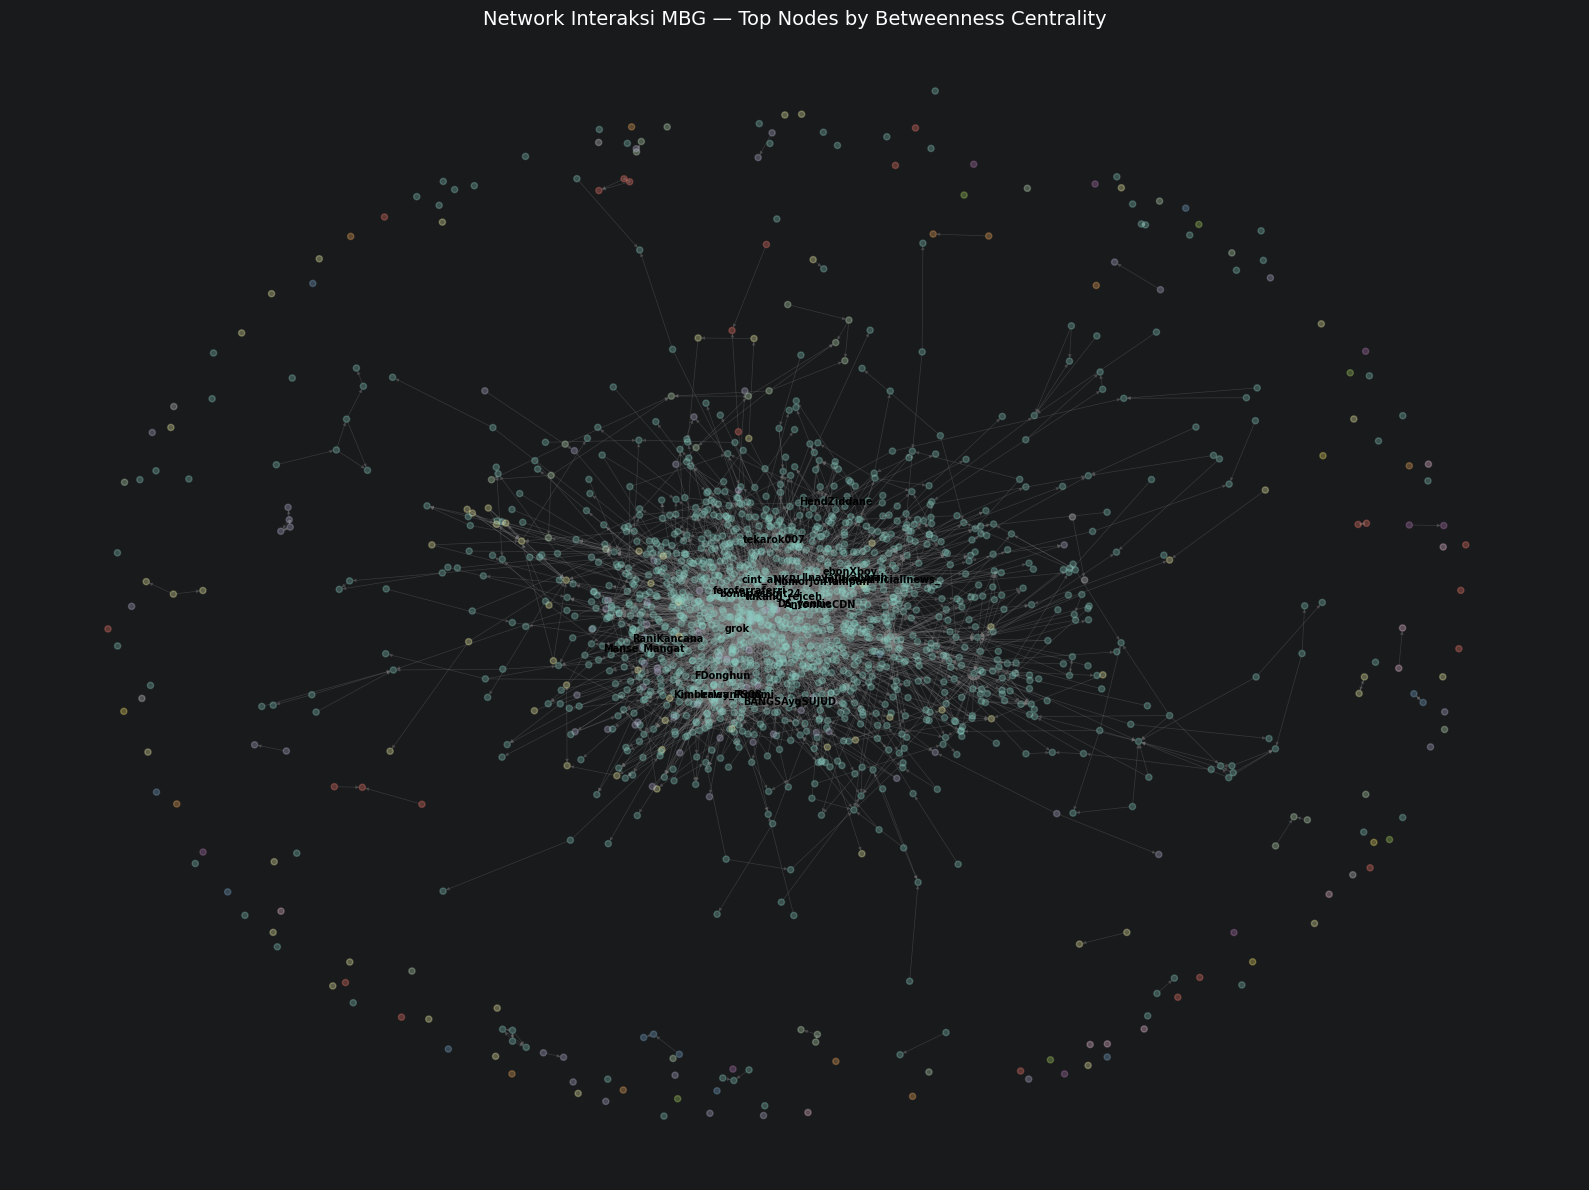

In [11]:
# Visualisasi dengan matplotlib (top nodes saja agar readable)
# Filter: hanya node dengan degree >= threshold
min_degree = 3
important_nodes = [n for n, d in G.degree() if d >= min_degree]
G_sub = G.subgraph(important_nodes).copy()
print(f"Subgraph untuk visualisasi: {G_sub.number_of_nodes()} nodes, {G_sub.number_of_edges()} edges")

# Layout
pos = nx.spring_layout(G_sub, k=0.5, iterations=50, seed=42)

# Warna berdasarkan komunitas
comm_colors = [partition.get(n, -1) for n in G_sub.nodes()]
node_sizes = [max(betweenness.get(n, 0) * 10000, 20) for n in G_sub.nodes()]

plt.figure(figsize=(16, 12))
nx.draw_networkx(
    G_sub, pos,
    node_color=comm_colors, cmap=plt.cm.Set3,
    node_size=node_sizes,
    with_labels=False,
    edge_color='gray', alpha=0.3,
    width=0.5, arrows=True, arrowsize=5
)

# Label hanya untuk top 20 nodes
top_nodes = sorted(G_sub.nodes(), key=lambda n: betweenness.get(n, 0), reverse=True)[:20]
labels = {n: n for n in top_nodes}
nx.draw_networkx_labels(G_sub, pos, labels, font_size=7, font_weight='bold')

plt.title('Network Interaksi MBG — Top Nodes by Betweenness Centrality', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig(f"{fig_net_dir}/network_communities.png", dpi=200, bbox_inches='tight')
plt.show()

In [12]:
# Interactive network visualization dengan pyvis
try:
    from pyvis.network import Network

    # Ambil top nodes saja (degree >= 5)
    top_threshold = 5
    top_nodes_pyvis = [n for n, d in G.degree() if d >= top_threshold]
    G_pyvis = G.subgraph(top_nodes_pyvis).copy()

    net = Network(height='700px', width='100%', directed=True, notebook=True)
    net.barnes_hut(gravity=-3000, central_gravity=0.3)

    # Warnai berdasarkan komunitas
    colors = ['#e6194B', '#3cb44b', '#ffe119', '#4363d8', '#f58231',
              '#911eb4', '#42d4f4', '#f032e6', '#bfef45', '#fabed4']

    for node in G_pyvis.nodes():
        comm = partition.get(node, 0)
        color = colors[comm % len(colors)]
        size = max(betweenness.get(node, 0) * 5000, 10)
        net.add_node(node, label=node, color=color, size=size, title=f"{node}\nCommunity: {comm}")

    for u, v, data in G_pyvis.edges(data=True):
        net.add_edge(u, v, value=data.get('weight', 1))

    net.save_graph(f"{fig_net_dir}/network_interactive.html")
    print(f"Interactive network saved to {fig_net_dir}/network_interactive.html")
except ImportError:
    print("pyvis not installed. Run: pip install pyvis")

pyvis not installed. Run: pip install pyvis


## P5-07: Save Results

In [14]:
# Merge community dan metrics ke df utama
df_final = df.merge(user_comm, on='username', how='left')
df_final = df_final.merge(betweenness_df, on='username', how='left')
df_final['betweenness'] = df_final['betweenness'].fillna(0)

# Influence score
max_f = df_final['user_followers_count'].clip(upper=100_000).max()
max_v = df_final['view_count'].clip(upper=50_000).max()
max_b = df_final['betweenness'].max()
df_final['influence_score'] = (
    (df_final['user_followers_count'].clip(upper=100_000) / max(max_f, 1)) * 0.3 +
    (df_final['view_count'].clip(upper=50_000) / max(max_v, 1)) * 0.4 +
    (df_final['betweenness'] / max(max_b, 1e-10)) * 0.3
)

# Save
df_final.to_csv(ANALYZED_DATA, index=False)
print(f"\nSaved to {ANALYZED_DATA}")
print(f"   {len(df_final)} rows, {len(df_final.columns)} columns")
print(f"   New columns: community, betweenness, influence_score")

# Save graph untuk reuse di Fase 6
import pickle
cache_dir = '../Data/Cache'
os.makedirs(cache_dir, exist_ok=True)
with open(f'{cache_dir}/network_graph.pkl', 'wb') as f:
    pickle.dump({'G_combined': G_combined, 'partition': partition, 'betweenness': betweenness}, f)
print(f"Graph saved to {cache_dir}/network_graph.pkl")


Saved to /Volumes/Livia's Storage/Users/Documents/Telkom_University/Outside_Classes/Competition/SatriaData/2026/internalTus/Data/Analyzed/mbg_analyzed.csv
   15000 rows, 57 columns
   New columns: community, betweenness, influence_score
Graph saved to ../Data/Cache/network_graph.pkl
